In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("AnimeList.csv")
print("loaded")

loaded


In [2]:
df.sort_values("score", ascending=False)[["title", "score", "members", "type"]].dropna().head(10)
df.columns

Index(['anime_id', 'title', 'title_english', 'title_japanese',
       'title_synonyms', 'image_url', 'type', 'source', 'episodes', 'status',
       'airing', 'aired_string', 'aired', 'duration', 'rating', 'score',
       'scored_by', 'rank', 'popularity', 'members', 'favorites', 'background',
       'premiered', 'broadcast', 'related', 'producer', 'licensor', 'studio',
       'genre', 'opening_theme', 'ending_theme'],
      dtype='str')

In [3]:
df.groupby("type")["score"].mean()

type
Movie      6.023003
Music      5.177479
ONA        5.415927
OVA        6.186495
Special    6.308249
TV         6.532639
Unknown    0.000000
Name: score, dtype: float64

In [4]:
df.groupby("source")["score"].mean()

source
4-koma manga     6.494286
Book             6.290968
Card game        6.052542
Digital manga    4.639000
Game             6.040165
Light novel      6.800391
Manga            6.763080
Music            5.200510
Novel            6.423621
Original         5.735413
Other            5.552549
Picture book     5.473750
Radio            5.488889
Unknown          5.977637
Visual novel     6.450822
Web manga        6.009067
Name: score, dtype: float64

In [5]:
df[
    df["members"] > 100000
    ].sort_values("score", ascending=False).head(3)

,anime_id,title,title_english,title_japanese,title_synonyms,image_url,type,source,episodes,status,...,background,premiered,broadcast,related,producer,licensor,studio,genre,opening_theme,ending_theme
2555,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,"Hagane no Renkinjutsushi: Fullmetal Alchemist,...",https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,64,Finished Airing,...,Fullmetal Alchemist: Brotherhood is an alterna...,Spring 2009,Sundays at 17:00 (JST),"{'Adaptation': [{'mal_id': 25, 'type': 'manga'...","Aniplex, Square Enix, Mainichi Broadcasting Sy...","Funimation, Aniplex of America",Bones,"Action, Military, Adventure, Comedy, Drama, Ma...","['#1: ""again"" by YUI (eps 1-14)', '#2: ""Hologr...","['#1: ""Uso (嘘)"" by SID (eps 1-14)', '#2: ""LET ..."
1028,32281,Kimi no Na wa.,Your Name.,君の名は。,NaN,https://myanimelist.cdn-dena.com/images/anime/...,Movie,Original,1,Finished Airing,...,NaN,NaN,NaN,"{'Adaptation': [{'mal_id': 99314, 'type': 'man...","Kadokawa Shoten, Toho, Sound Team Don Juan, La...","Funimation, NYAV Post",CoMix Wave Films,"Supernatural, Drama, Romance, School","['""Yume Tourou (夢灯籠)"" by RADWIMPS']","['""Nandemonaiya (なんでもないや)"" by RADWIMPS']"
1252,28977,Gintama°,Gintama Season 4,銀魂°,Gintama&#039; (2015),https://myanimelist.cdn-dena.com/images/anime/...,TV,Manga,51,Finished Airing,...,This is a fourth season of Gintama. In the ep...,Spring 2015,Wednesdays at 18:00 (JST),"{'Adaptation': [{'mal_id': 44, 'type': 'manga'...","TV Tokyo, Aniplex, Dentsu","Funimation, Crunchyroll",Bandai Namco Pictures,"Action, Comedy, Historical, Parody, Samurai, S...","['#1: ""DAY×DAY"" by BLUE ENCOUNT (eps 1-12)', '...","['#1: ""DESTINY"" by Negoto (eps 1-12)', '#2: ""S..."


<Axes: xlabel='members', ylabel='score'>

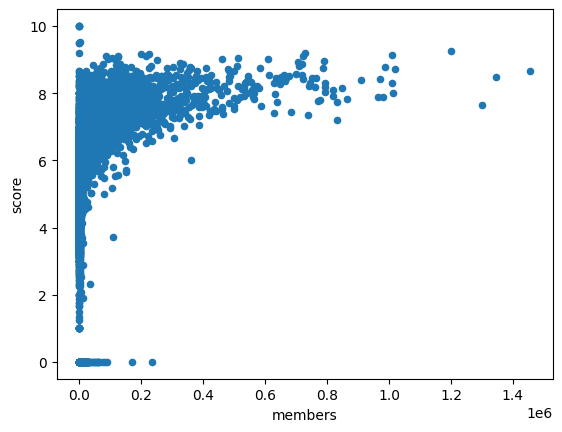

In [6]:
df.plot.scatter(x="members", y="score")

In [7]:
df.groupby("studio")["members"].mean().sort_values(ascending=False).head(10)

studio
Gainax, Tatsunoko Production          641101.000000
Madhouse, Satelight, Graphinica       425255.000000
Silver Link., Nexus                   336877.000000
Kyoto Animation, Animation Do         277420.500000
A-1 Pictures, Trigger, CloverWorks    276912.000000
Gainax, Production I.G                274696.666667
Kinema Citrus, Orange                 251132.000000
Ordet, SANZIGEN                       245436.000000
Hal Film Maker, TYO Animations        244791.000000
Satelight, A-1 Pictures               230361.200000
Name: members, dtype: float64

In [8]:
df.isnull().sum().sort_values(ascending=False)

background        13421
licensor          11105
premiered         10382
broadcast         10207
title_english      8754
producer           6190
studio             5934
title_synonyms     5541
rank               1574
rating              544
image_url            96
genre                64
title_japanese       35
title                 0
anime_id              0
duration              0
aired                 0
aired_string          0
airing                0
episodes              0
status                0
source                0
type                  0
members               0
favorites             0
scored_by             0
popularity            0
score                 0
related               0
opening_theme         0
ending_theme          0
dtype: int64

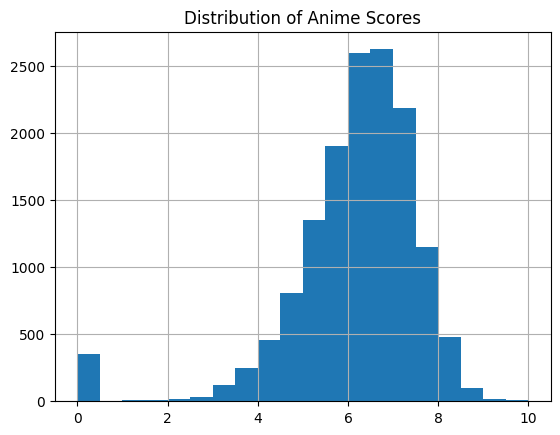

In [9]:
df["score"].hist(bins=20)
plt.title("Distribution of Anime Scores")
plt.show()

In [10]:
df["score"].corr(df["members"])

np.float64(0.3054824841912712)

In [11]:
df["members"].corr(df["favorites"])

np.float64(0.7761645306589096)

In [31]:
df["studio"].sample(20).dropna()

7509                  Remic
8479      TMS Entertainment
5035         Toei Animation
569                 Sunrise
13372                 Xebec
10044           Studio Deen
9742      TMS Entertainment
6215                  MAPPA
11793                 Shaft
11952               Sunrise
4184     Tezuka Productions
12793        Pie in The Sky
8993                   8bit
2966           Silver Link.
4972       Nippon Animation
9977                Sunrise
Name: studio, dtype: str

In [53]:
studio_df = df[["studio", "score"]].copy()
studio_df["studio"] = studio_df["studio"].str.split(", ")
studio_df = studio_df.explode("studio")

studio_stats = studio_df.groupby("studio").agg(
    avg_score=("score", "mean"),
    anime_count=("score", "count")
)

studio_stats[
    studio_stats["anime_count"] >= 20
].sort_values("avg_score", ascending=False).head(15)

,avg_score,anime_count
studio,,
Tokyo Movie Shinsha,7.280345,29
Hal Film Maker,7.235333,30
Seven Arcs,7.233810,21
Shaft,7.185750,120
Brain&#039;s Base,7.175116,86
Manglobe,7.110882,34
Bones,7.099145,117
Artland,7.095000,48
Studio Comet,7.089722,36
